In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [2]:
words = open(file='./data/names.txt',mode='r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {k: v+1 for v, k in enumerate(chars)}
stoi['.'] = 0
itos = {k: v for v, k in stoi.items()}
print(len(stoi))
vocab_size = len(stoi)

27


In [4]:
### builde the dataset
block_size = 3
X, Y = [], []
def build_dataset(data):
    for w in data:
        context = [0] *3 
        chs = w + '.'
        for ch in chs:
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)
np.random.seed(42)
words = np.random.permutation(words)

n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [5]:
def cmp(s,dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.all(torch.isclose(dt, t.grad)).item()
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {str(maxdiff)}')

In [6]:
nemd = 10
n_hidden = 100
g = torch.Generator().manual_seed(0)
C = torch.randn(size = (vocab_size, nemd),generator= g)

W1 = torch.randn(size = (block_size * nemd, n_hidden), generator= g) * (5/3) / ((block_size * nemd) ** 0.5)
b1 = torch.randn(size = (n_hidden,) ,generator= g) * 0.1
 
W2 = torch.randn(size = (n_hidden, vocab_size), generator= g) * 0.1
b2 = torch.randn(size = (vocab_size,), generator= g) * 0.1

bngain = torch.ones(size=(1,n_hidden))*0.1 + 0.1
bnbias = torch.zeros(size=(1,n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

In [7]:
batch_size = 32
n = batch_size
ix = torch.randint(0, Xtr.shape[0], (n,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]
print(Xtr.shape, Ytr.shape) # (32033, 3) (32033,)
print(Xb.shape, Yb.shape) # (32, 3) (32,)

torch.Size([182671, 3]) torch.Size([182671])
torch.Size([32, 3]) torch.Size([32])


In [8]:
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hprebn = embcat @ W1 + b1 ### shape: (32, 300) @ (300, 100) + (100,) -> (32, 100)
# batchnorm
bnmeani = 1/n * hprebn.sum(0, keepdim=True)### shape: (1, 100)
# bnvar = 1/n * ((hprebn - bnmeani)**2).sum(0, keepdim=True)### shape: (1, 100)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n - 1) * bndiff2.sum(0, keepdim=True) ### shape: (1, 100)
bnvar_inv = (bnvar + 1e-5)**-0.5 #
bnraw = bndiff * bnvar_inv #
hpreact = bngain * bnraw + bnbias  #
h = torch.tanh(hpreact) #
logits = h @ W2 + b2### shape: (32, 100) @ (100, 27) + (27,) -> (32, 27) #
logits_max = torch.max(logits, dim=1, keepdim=True)[0] #
norm_logits = logits - logits_max #
counts = norm_logits.exp() ### shape: (32, 27) #
counts_sum = counts.sum(1, keepdim=True) ### shape: (32, 1) #
counts_sum_inv = counts_sum**-1#
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(batch_size), Yb].mean()

### Pytorch backward pass
for p in parameters:
    p.grad = None
# for t in [logprobs,probs, counts, counts_sum, counts_sum_inv, norm_logits, logits_max,logits, h, hpreact, bnraw, bnvar_inv, bnvar, bndiff2, bndiff, bnmeani, hprebn, embcat, emb]:
#     t.retain_grad()### 
tensors = [logprobs, probs, counts, counts_sum, counts_sum_inv, norm_logits,
           logits_max, logits, h, hpreact, bnraw, bnvar_inv, bnvar,
           bndiff2, bndiff, bnmeani, hprebn, embcat, emb]

for t in tensors:
    if t.requires_grad:
        t.retain_grad()

loss.backward()
loss

tensor(3.2573, grad_fn=<NegBackward0>)

In [9]:
bndiff.shape,bnvar_inv.shape, bnraw.shape,bnvar.shape

(torch.Size([32, 100]),
 torch.Size([1, 100]),
 torch.Size([32, 100]),
 torch.Size([1, 100]))

In [10]:
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(batch_size), Yb] = -1.0 / batch_size
cmp('logprobs', dlogprobs, logprobs)

dprobs = (1.0 / probs) * dlogprobs
cmp('probs', dprobs, probs)

dcounts_sum_inv = (counts * dprobs).sum(dim= 1, keepdim=True) ### boardcasting ---> sum 
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)

dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**(-2)) * dcounts_sum_inv
cmp('counts_sum', dcounts_sum, counts_sum)

dcounts += torch.ones_like(counts) * dcounts_sum ### !!!! 
cmp('counts', dcounts, counts)

dnorm_logits = norm_logits.exp() * dcounts
cmp('norm_logits', dnorm_logits, norm_logits)

dlogits =  dnorm_logits.clone()
dlogits_max = -(dnorm_logits.clone()).sum(dim=1, keepdim=True)
dlogits += F.one_hot(logits.max(1).indices, num_classes= logits.shape[1]) * dlogits_max
cmp('logits_max', dlogits_max, logits_max)
cmp('logits', dlogits, logits)

dh = dlogits @ W2.T
cmp('h', dh, h)

dW2 = h.T @ dlogits
cmp('W2', dW2, W2)

db2 = dlogits.sum(0)
cmp('b2', db2, b2)

dhpreact = (1-h**2) * dh
cmp('hpreact', dhpreact, hpreact)

dbngain = (dhpreact * bnraw).sum(0, keepdim = True)
cmp('bngain',dbngain, bngain)

dbnbias = (dhpreact).sum(0, keepdim = True)
cmp('bnbias', dbnbias,bnbias)

dbnraw = dhpreact * bngain
cmp('bnraw', dbnraw, bnraw)

dbndiff = dbnraw * bnvar_inv
cmp('bndiff', dbndiff, bndiff)

dbnvar_inv = (dbnraw * bndiff).sum(0, keepdim = True)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)

dbnvar = dbnvar_inv * (-0.5 *((bnvar + 1e-5)**-1.5))
cmp('bnvar', dbnvar, bnvar)

dbndiff2 = dbnvar * (1.0 / (n-1) * torch.ones_like(bndiff2))
cmp('bndiff2', dbndiff2, bndiff2)

dbndiff += 2*bndiff*dbndiff2
cmp('bndiff', dbndiff, bndiff)

dhprebn = dbndiff
cmp('hprebn', dhprebn, hprebn)

dbnmeani = - dbndiff.sum(0)
cmp('dbnmeani', dbnmeani, bnmeani)

dhprebn +=  1/n * torch.ones_like(hprebn)* dbnmeani
cmp('hprebn', dhprebn, hprebn)

dembcat = dhprebn @ W1.T
cmp('embcat', dembcat, embcat)

dW1 = embcat.T @ dhprebn
cmp('W1', dW1, W1)

db1 = dhprebn.sum(0)
cmp('b1', db1, b1)

demb = dembcat.view(emb.shape) ### 反视图
cmp('emb', demb, emb)

dC = torch.zeros_like(C)
for j in range(Xb.shape[0]):
    for k in range(Xb.shape[1]):
        ix = Xb[j,k]
        dC[ix] += demb[j,k]
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logits_max      | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

### `dlogits` 推导过程

**前向传播流程：**
$$x \xrightarrow{W} \text{logits} \xrightarrow{\text{Softmax}} \text{probs} \xrightarrow{\text{取第 } j \text{ 项}} \text{Prob}[j] \xrightarrow{-\log} -\log(\text{Prob}[j]) = \text{loss}$$

**Loss 函数定义：**
$$\text{loss} = -\log(\text{Prob}[j]) = -\log \frac{e^{l_j}}{\sum e^{l_s}}$$

---

**1. 当 $i \neq j$ 时对 $l_i$ 的偏导：**

首先写出 loss 函数：
$$\text{loss} = -\log \frac{e^{l_j}}{\sum e^{l_s}}$$

利用链式法则求导：
$$\frac{d(\text{loss})}{dl_i} = - \frac{\sum e^{l_s}}{e^{l_j}} \cdot \frac{-e^{l_j} e^{l_i}}{(\sum e^{l_s})^2} \quad (i \neq j)$$

化简得到：
$$= p_i$$

---

**2. 当求导目标为真实类别 $l_j$ 时的偏导：**

$$\frac{d(\text{loss})}{dl_j} = - \frac{\sum e^{l_s}}{e^{l_j}} \cdot \frac{e^{l_j} \sum e^{l_s} - e^{l_j} e^{l_j}}{(\sum e^{l_s})^2}$$

约分化简：
$$= - \frac{\sum e^{l_s} - e^{l_j}}{\sum e^{l_s}}$$

最终结果：
$$= p_j - 1$$

前面我们推导出了 Softmax 交叉熵损失函数对 logits ($l$) 的偏导数。这组公式非常优雅，它在神经网络的训练中直观地体现了“梯度的推拉作用”（Push-Pull Effect）。

结合前面推导的结果，我们来深入解析一下这种作用的物理意义。

### 1. 公式的直观解读

回顾我们推导出的偏导数（假设真实标签类别为 $j$）：

* **对于非目标类别 ($i \neq j$)：** $\frac{\partial \text{loss}}{\partial l_i} = p_i$
* **对于目标类别 ($j$)：** $\frac{\partial \text{loss}}{\partial l_j} = p_j - 1$

在神经网络中，参数更新遵循梯度下降（Gradient Descent）的原则：变量会向着梯度的反方向更新，即 $l_{new} = l_{old} - \eta \cdot \text{gradient}$（$\eta$ 为学习率）。

####  “拉”的作用 (Pull) - 针对目标类别 $j$
目标类别的梯度是 $p_j - 1$。
因为概率 $p_j$ 的范围是 $(0, 1]$，所以 $p_j - 1$ 必定是一个负数或 $0$。
当我们执行梯度下降时：$l_j \leftarrow l_j - \eta \cdot (p_j - 1)$，由于 $(p_j - 1)$ 是负的，相当于加上了一个正数。
* **结论：** 梯度在“拉高”目标类别的 logit 值，鼓励模型对正确类别输出更大的分数。
* **误差驱动：** 如果模型预测很准（$p_j \approx 1$），梯度接近 $0$，几乎不拉；如果预测很离谱（$p_j \approx 0$），梯度接近 $-1$，会产生很强的拉力。

####  “推”的作用 (Push) - 针对非目标类别 $i$
非目标类别的梯度是 $p_i$。
因为概率 $p_i$ 的范围是 $[0, 1)$，所以 $p_i$ 必定是一个正数或 $0$。
当我们执行梯度下降时：$l_i \leftarrow l_i - \eta \cdot p_i$，相当于减去了一个正数。
* **结论：** 梯度在“推低”所有错误类别的 logit 值，压制错误类别的分数。
* **惩罚出头鸟：** 如果某个错误类别 $i$ 被赋予了很高的概率（$p_i$ 很大），它受到的“向下推”的惩罚力度就越大；如果它本身概率已经很低（$p_i \approx 0$），推力就微乎其微。

---

### 2. 零和博弈 (Zero-Sum)

如果你把所有类别的梯度加起来，会发现一个有趣的现象：
$$\sum_{k} \frac{\partial \text{loss}}{\partial l_k} = \sum_{i \neq j} p_i + (p_j - 1) = \left( \sum_{all} p_k \right) - 1 = 1 - 1 = 0$$

这意味着 Softmax 交叉熵的梯度具有“零和”属性。梯度的总能量是守恒的：模型往正确类别上“拉”了多少力气，就会等价地往所有错误类别上“推”多少力气。这是一种相对的竞争机制。

logits          | exact: False | approximate: True  | maxdiff: 4.889443516731262e-09
tensor(-1.8626e-09, grad_fn=<SumBackward0>)


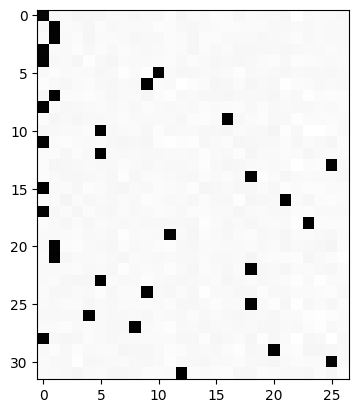

In [ ]:
### 另一种方法 计算loss的时候 使用crossentropy计算
dlogits = F.softmax(logits, dim=1)
dlogits[range(n), Yb] -= 1
dlogits /= n
cmp('logits', dlogits, logits) # | exact: False | approximate: True  | maxdiff: 4.889443516731262e-09
print(dlogits[0].sum()) ### tensor(-1.8626e-09, grad_fn=<SumBackward0>) 0 因此每一行 代表 输出头 梯度的和为0 也很好推导
plt.imshow(dlogits.detach(), cmap = 'gray')


In [ ]:
from d2l import torch as d2l
